# Objective of this analysis is to answer "What drives housing prices in California?"

### import necessary libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv("housing.csv")

### Understand the dataset

In [3]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


### Handling missing values

<Axes: >

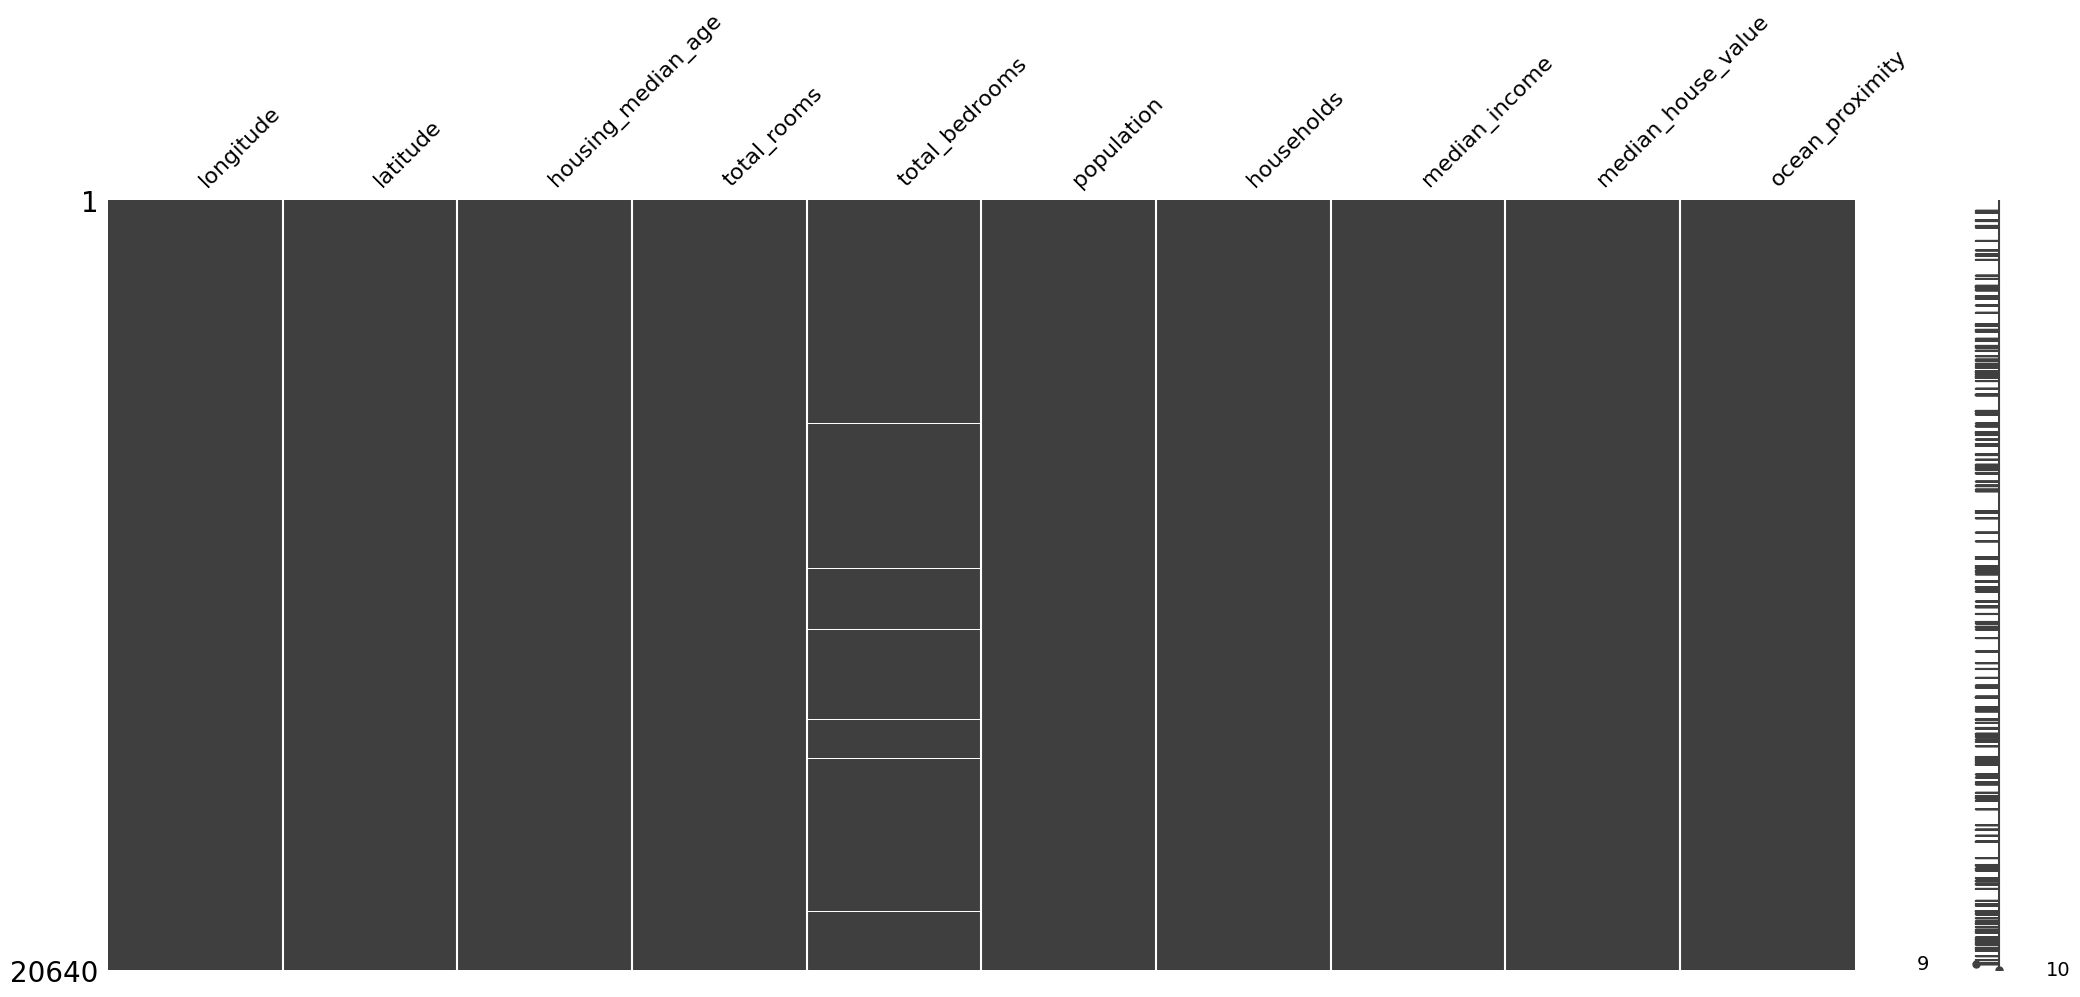

In [5]:
msno.matrix(df)

In [6]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

### There is only missing value in total_bedrooms.We can't drop all 207 rows rather we can fill them with median value. But for that we need to chech a few things at first

In [7]:
df['ocean_proximity'].unique()

<StringArray>
['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND']
Length: 5, dtype: str

In [8]:
df.groupby("ocean_proximity")["total_bedrooms"].median()

ocean_proximity
<1H OCEAN     438.0
INLAND        423.0
ISLAND        512.0
NEAR BAY      423.0
NEAR OCEAN    464.0
Name: total_bedrooms, dtype: float64

In [9]:
df['total_bedrooms'] = df.groupby('ocean_proximity')['total_bedrooms'].transform(
    lambda x: x.fillna(x.median())
)

# Univariate Analysis

### Before jumping to correlations or models, an analyst first understands each variable individually. This is called univariate analysis.

# About your target variable median_house_value:
    What does the distribution look like — is it spread out or concentrated?
    Is it skewed? Remember the max was capped at $500,001
    Where do most house values cluster?

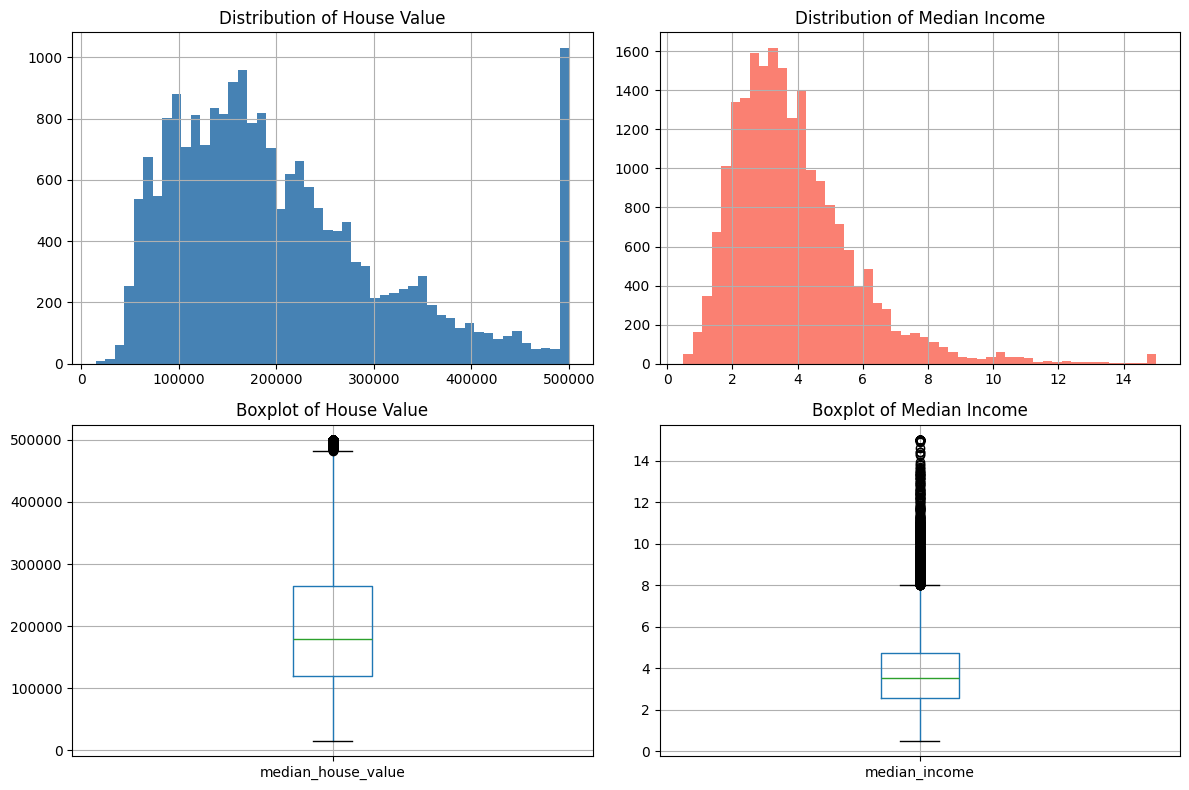

In [10]:
# Let's visualize the distribution at first
figfig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Histograms
df['median_house_value'].hist(bins=50, ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Distribution of House Value')

df['median_income'].hist(bins=50, ax=axes[0, 1], color='salmon')
axes[0, 1].set_title('Distribution of Median Income')

# Boxplots
df.boxplot(column='median_house_value', ax=axes[1, 0])
axes[1, 0].set_title('Boxplot of House Value')

df.boxplot(column='median_income', ax=axes[1, 1])
axes[1, 1].set_title('Boxplot of Median Income')

plt.tight_layout()
plt.show()

# Understanding outliers
    there is a sudden spike at 500000. Are these outliers real data or data artifacts? 

In [11]:
# How many rows hit the cap exactly?
print(df[df['median_house_value'] == 500001].shape[0])

# Any values above the cap?
print(df[df['median_house_value'] > 500001].shape[0])

# See the top 10 highest values
print(df['median_house_value'].nlargest(10))

965
0
89     500001.0
459    500001.0
493    500001.0
494    500001.0
509    500001.0
510    500001.0
511    500001.0
512    500001.0
514    500001.0
517    500001.0
Name: median_house_value, dtype: float64


###  What does this tell us?
    965 rows don't have their true house value recorded — they just hit the ceiling. The real values could be $600k, $800k, $1M+ — we simply don't know.
    This is called censored data — a very common real-world data quality issue.

### 965 rows out of 20,640 = ~4.7% of your data.as our goal is "understand typical California housing" → dropping 4.7% is acceptable

In [12]:
Q1 = df['median_house_value'].quantile(0.25)
Q3 = df['median_house_value'].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

df_clean = df[df['median_house_value'] <= upper_bound]

print('Before:', df.shape[0])
print('After:', df_clean.shape[0])
print('Removed:', df.shape[0] - df_clean.shape[0])

Before: 20640
After: 19569
Removed: 1071


In [13]:
print('Upper bound:', upper_bound)
print('Max after cleaning:', df_clean['median_house_value'].max())

Upper bound: 482412.5
Max after cleaning: 482200.0


In [14]:
print(df['median_income'].max())
print(df[df['median_income'] == df['median_income'].max()].shape[0])

15.0001
49


## Every outlires shouldn't be removed.There can be some rich people in the city and the number seems natural

# Feature Engineering 

### Remember the three derived features from earlier — block-level totals are misleading without context.

In [15]:
df_clean['rooms_per_household']       = df_clean['total_rooms'] / df_clean['households']
df_clean['bedrooms_per_room']         = df_clean['total_bedrooms'] / df_clean['total_rooms']
df_clean['population_per_household']  = df_clean['population'] / df_clean['households']

In [16]:
df_clean.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_household,bedrooms_per_room,population_per_household
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,6.984127,0.146591,2.555556
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,6.238137,0.155797,2.109842
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,8.288136,0.129516,2.802260
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,5.817352,0.184458,2.547945
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,6.281853,0.172096,2.181467


In [17]:
print(df_clean[['rooms_per_household', 'bedrooms_per_room', 'population_per_household']].describe())

       rooms_per_household  bedrooms_per_room  population_per_household
count         19569.000000       19569.000000              19569.000000
mean              5.357548           0.215875                  3.098760
std               2.294996           0.064438                 10.660526
min               0.846154           0.036126                  0.692308
25%               4.413567           0.177622                  2.448193
50%               5.181818           0.204678                  2.839009
75%               5.965142           0.241331                  3.307692
max             132.533333           2.746753               1243.333333


### rooms_per_household and population_per_household max value looks suspicious.If households is very small — say 1 or 2 — but total_rooms is large, the ratio explodes artificially.This is called a ratio instability problem — small denominators create extreme ratios.

In [18]:
# What are the max values?
print(df_clean['rooms_per_household'].max())
print(df_clean['population_per_household'].max())

# How many rows are extremely high?
print(df_clean[df_clean['rooms_per_household'] > 50].shape[0])
print(df_clean[df_clean['population_per_household'] > 50].shape[0])

# What do those rows look like?
print(df_clean[df_clean['rooms_per_household'] > 50][['total_rooms', 'households', 'rooms_per_household']])

132.53333333333333
1243.3333333333333
8
7
       total_rooms  households  rooms_per_household
1912        1463.0        26.0            56.269231
1913        2967.0        48.0            61.812500
1979        1988.0        15.0           132.533333
2395        1881.0        37.0            50.837838
9676        5919.0       112.0            52.848214
11707       2213.0        42.0            52.690476
11862        958.0        16.0            59.875000
12447       2809.0        45.0            62.422222


### A large family home might have 10-15 rooms. A small apartment maybe 3-4. So anything above say 50 is almost certainly a data anomaly.So treat them as outliers and remove them.

In [19]:
for col in ['rooms_per_household', 'population_per_household']:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * Q3
    df_clean = df_clean[df_clean[col] <= upper_bound]
    print(f'{col} → upper bound: {upper_bound:.2f}, remaining rows: {df_clean.shape[0]}')

rooms_per_household → upper bound: 14.91, remaining rows: 19462
population_per_household → upper bound: 8.28, remaining rows: 19417


# Label encoding

### Think First — why encode at all?
    Ask yourself:
    Can a machine learning model understand the text "NEAR OCEAN" or "INLAND"?
    No — ML models only understand numbers. So yes, ocean_proximity must be encoded 

### Option 1 — Label Encoding
    Assigns a number to each category:
    INLAND      → 0
    NEAR OCEAN  → 1
    NEAR BAY    → 2
    <1H OCEAN   → 3
    ISLAND      → 4
    ⚠️ Problem — implies order. Is ISLAND really "greater than" INLAND? No! Categories have no natural ranking here.
### Option 2 — One Hot Encoding
    Creates a separate binary column for each category:


#  Key question to decide:
    Does ocean_proximity have a natural order?
    What do you think — is there a natural order between INLAND, NEAR BAY, NEAR OCEAN, and ISLAND? 
    let's find out

In [20]:
df_clean.groupby('ocean_proximity')['median_house_value'].median().sort_values(ascending=False)

ocean_proximity
ISLAND        414700.0
NEAR BAY      218550.0
NEAR OCEAN    216100.0
<1H OCEAN     206900.0
INLAND        107550.0
Name: median_house_value, dtype: float64

### So the order should be'INLAND'<'<1H OCEAN'<'NEAR OCEAN'<'NEAR BAY'<'ISLAND'

In [21]:
order_map = {
    'INLAND': 0,
    '<1H OCEAN': 1,
    'NEAR OCEAN': 2,
    'NEAR BAY': 3,
    'ISLAND': 4
}

df_clean['ocean_proximity_encoded'] = df_clean['ocean_proximity'].map(order_map)
# Verify
print(df_clean[['ocean_proximity', 'ocean_proximity_encoded']].drop_duplicates().sort_values('ocean_proximity_encoded'))

     ocean_proximity  ocean_proximity_encoded
954           INLAND                        0
701        <1H OCEAN                        1
1850      NEAR OCEAN                        2
0           NEAR BAY                        3
8314          ISLAND                        4


# Correlation Analysis

In [22]:
df_clean.corr(numeric_only=True)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household,ocean_proximity_encoded
longitude,1.000000,-0.926849,-0.101714,0.041916,0.067345,0.103087,0.056289,-0.010937,-0.047139,-0.064092,0.086583,0.182570,-0.253908
latitude,-0.926849,1.000000,0.010040,-0.032573,-0.066929,-0.111351,-0.068633,-0.076856,-0.148700,0.137220,-0.112815,-0.179650,-0.006422
housing_median_age,-0.101714,0.010040,1.000000,-0.374546,-0.328483,-0.303246,-0.317427,-0.198945,0.060570,-0.256938,0.154838,0.017454,0.283681
total_rooms,0.041916,-0.032573,-0.374546,1.000000,0.930487,0.872942,0.927236,0.227988,0.147469,0.239528,-0.189400,-0.105676,-0.034186
total_bedrooms,0.067345,-0.066929,-0.328483,0.930487,1.000000,0.888056,0.979553,0.024883,0.078130,0.005003,0.062675,-0.142775,-0.006215
population,0.103087,-0.111351,-0.303246,0.872942,0.888056,1.000000,0.916391,0.045145,0.016848,-0.032737,0.000386,0.178263,-0.035256
households,0.056289,-0.068633,-0.317427,0.927236,0.979553,0.916391,1.000000,0.049135,0.097369,-0.046441,0.023346,-0.127242,0.010845
median_income,-0.010937,-0.076856,-0.198945,0.227988,0.024883,0.045145,0.049135,1.000000,0.646418,0.596233,-0.553207,-0.051652,0.140174
median_house_value,-0.047139,-0.148700,0.060570,0.147469,0.078130,0.016848,0.097369,0.646418,1.000000,0.222593,-0.196321,-0.245069,0.403237
rooms_per_household,-0.064092,0.137220,-0.256938,0.239528,0.005003,-0.032737,-0.046441,0.596233,0.222593,1.000000,-0.672646,-0.048635,-0.145121


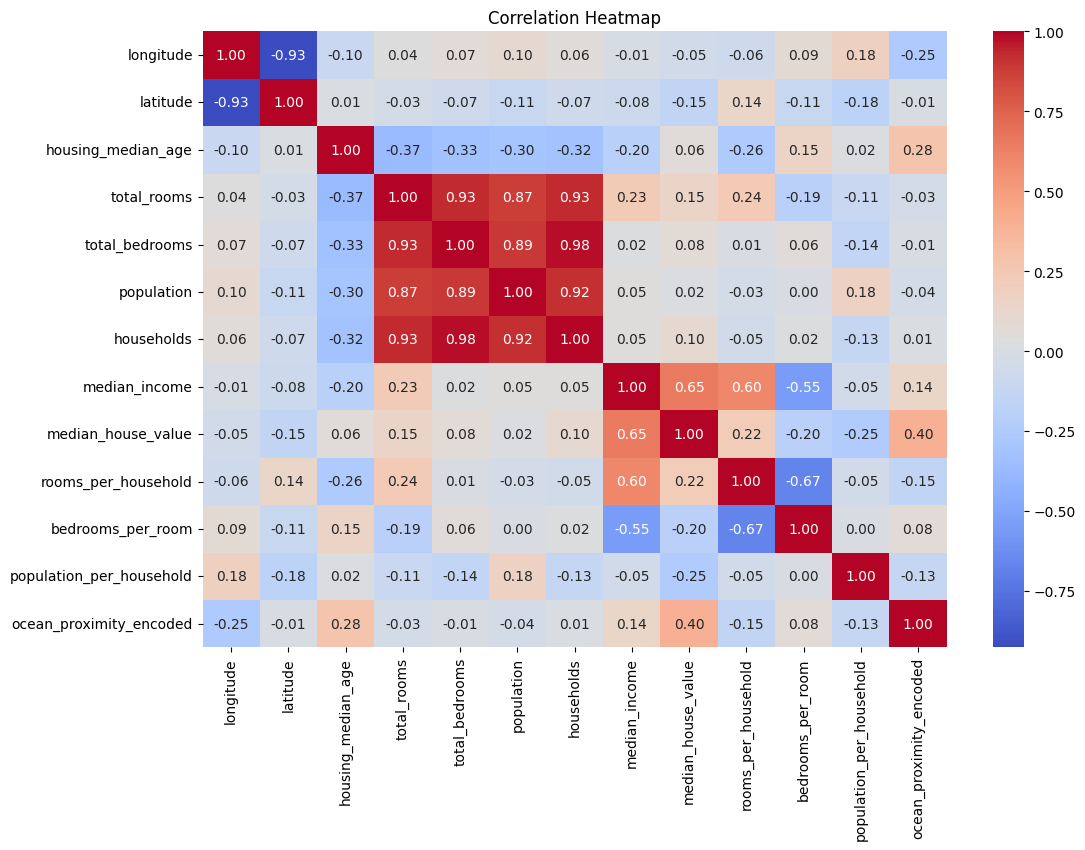

In [23]:
plt.figure(figsize=(12, 8))
sns.heatmap(df_clean.select_dtypes(include='number').corr(), 
            annot=True,      
            cmap='coolwarm',
            fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [24]:
print(df_clean['median_income'].corr(df_clean['median_house_value']))

0.6464178224400334


In [25]:
# Get all correlations with target, sorted
corr_with_target = df_clean.select_dtypes(include='number').corr()['median_house_value'].sort_values(ascending=False)
print(corr_with_target)

median_house_value          1.000000
median_income               0.646418
ocean_proximity_encoded     0.403237
rooms_per_household         0.222593
total_rooms                 0.147469
households                  0.097369
total_bedrooms              0.078130
housing_median_age          0.060570
population                  0.016848
longitude                  -0.047139
latitude                   -0.148700
bedrooms_per_room          -0.196321
population_per_household   -0.245069
Name: median_house_value, dtype: float64


### It seems median income and ocen_proximity have huge impact on house value

# But there are some features they are highly correlated among themselves that creates Multicolinearity. In this particular case we should remove them

In [26]:
cols_to_drop = ['total_rooms', 'total_bedrooms', 'population', 'households', 'bedrooms_per_room']
df_clean = df_clean.drop(columns=cols_to_drop)
print(df_clean.columns.tolist())

['longitude', 'latitude', 'housing_median_age', 'median_income', 'median_house_value', 'ocean_proximity', 'rooms_per_household', 'population_per_household', 'ocean_proximity_encoded']


# Exploratory Visualization

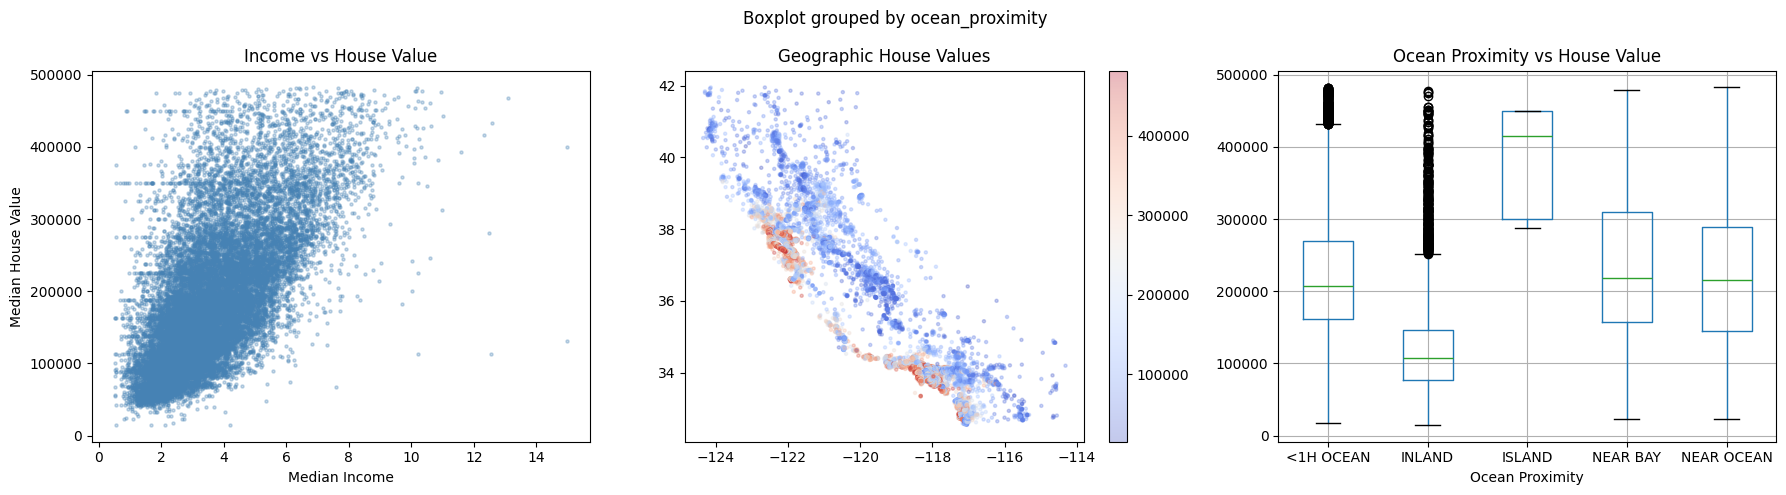

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1 — Income vs House Value
axes[0].scatter(df_clean['median_income'], 
                df_clean['median_house_value'], 
                alpha=0.3, color='steelblue', s=5)
axes[0].set_xlabel('Median Income')
axes[0].set_ylabel('Median House Value')
axes[0].set_title('Income vs House Value')

# Plot 2 — Geographic plot
scatter = axes[1].scatter(df_clean['longitude'], 
                          df_clean['latitude'],
                          c=df_clean['median_house_value'],
                          cmap='coolwarm', alpha=0.3, s=5)
plt.colorbar(scatter, ax=axes[1])
axes[1].set_title('Geographic House Values')

# Plot 3 — Ocean Proximity vs House Value
df_clean.boxplot(column='median_house_value', 
                 by='ocean_proximity', 
                 ax=axes[2])
axes[2].set_title('Ocean Proximity vs House Value')
axes[2].set_xlabel('Ocean Proximity')

plt.tight_layout()
plt.show()

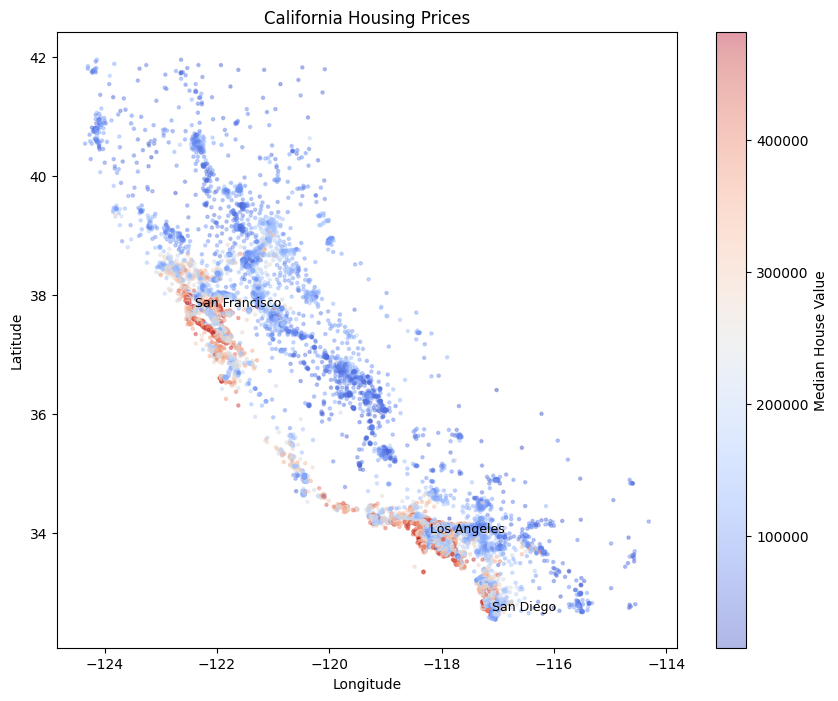

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.scatter(df_clean['longitude'], 
            df_clean['latitude'],
            c=df_clean['median_house_value'],
            cmap='coolwarm', alpha=0.4, s=5)
plt.colorbar(label='Median House Value')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('California Housing Prices')

# Add region annotations
plt.annotate('San Francisco', xy=(-122.4, 37.8), fontsize=9, color='black')
plt.annotate('Los Angeles', xy=(-118.2, 34.0), fontsize=9, color='black')
plt.annotate('San Diego', xy=(-117.1, 32.7), fontsize=9, color='black')

plt.show()

### It seems San Francisco has more high price houses then Los Angeles then San diego

# Model Training

### 👉 One last question before ML:
    You have longitude and latitude as separate features — but your geographic plot shows they work together to define location.
    Should you keep them as separate features, or is there a smarter way to use them in ML?

In [29]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=10, random_state=42)
df_clean['location_cluster'] = kmeans.fit_predict(df_clean[['longitude', 'latitude']])

### So our final feature set for ML

In [30]:
features = [
    'longitude',
    'latitude', 
    'housing_median_age',
    'median_income',
    'ocean_proximity_encoded',
    'rooms_per_household',
    'population_per_household'
]

X = df_clean[features]
y = df_clean['median_house_value']

In [31]:
print(y.head(10))

0    452600.0
1    358500.0
2    352100.0
3    341300.0
4    342200.0
5    269700.0
6    299200.0
7    241400.0
8    226700.0
9    261100.0
Name: median_house_value, dtype: float64


# Now let's build model step by step:
    Step 1 — Train/Test split:

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 20% for testing
    random_state=42     # reproducibility
)

print('Training size:', X_train.shape)
print('Testing size:', X_test.shape)

Training size: (15533, 7)
Testing size: (3884, 7)


## Step 2 — Train Linear Regression:

In [33]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


# Step 3 — Evaluate:

In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'MAE:  ${mae:,.0f}')
print(f'RMSE: ${rmse:,.0f}')
print(f'R²:   {r2:.4f}')

MAE:  $43,520
RMSE: $57,543
R²:   0.6302


### 🧠 Is this good or bad?
    R² of 0.63 falls in the moderate zone — the model learned something meaningful but is clearly missing patterns.

# Ask yourself — why might Linear Regression struggle here?
    Remember your scatter plot of median_income vs median_house_value — was it a perfectly straight line?
    No! It was curved and scattered — meaning the relationship is non-linear. Linear Regression can only draw straight lines through data!

# Random Forest Model

In [36]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2 = r2_score(y_test, y_pred_rf)

print(f'MAE:  ${mae:,.0f}')
print(f'RMSE: ${rmse:,.0f}')
print(f'R²:   {r2:.4f}')

MAE:  $28,082
RMSE: $41,953
R²:   0.8034


## But we shoul ask ourself — is 0.80 good enough?
    For a research project → ✅ Excellent
    For a real estate business → ⚠️ $28k average error is still significant
    For a Kaggle competition → ⚠️ Could push higher with tuning

In [38]:
y_pred_train = model_rf.predict(X_train)
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_rf)

print(f'R² Train: {r2_train:.4f}')
print(f'R² Test:  {r2_test:.4f}')

R² Train: 0.9713
R² Test:  0.8034


### That's a significant gap — let's diagnose it!

### The model memorized the training data instead of learning general patterns!
    Why does Random Forest overfit?
    Each tree in Random Forest can grow very deep — eventually memorizing every single training row.
    It's like a student memorizing every practice question word for word — fails on slightly different exam questions!

In [40]:
model_rf2 = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,              # limit tree depth
    min_samples_split=10,      # need at least 10 samples to split
    random_state=42
)
model_rf2.fit(X_train, y_train)

y_pred_train2 = model_rf2.predict(X_train)
y_pred_test2 = model_rf2.predict(X_test)

print(f'R² Train: {r2_score(y_train, y_pred_train2):.4f}')
print(f'R² Test:  {r2_score(y_test, y_pred_test2):.4f}')
print(f'MAE:  ${mean_absolute_error(y_test, y_pred_test2):,.0f}')
print(f'RMSE: ${np.sqrt(mean_squared_error(y_test, y_pred_test2)):,.0f}')

R² Train: 0.9175
R² Test:  0.7993
MAE:  $28,686
RMSE: $42,388


### What's happening?
    Training score came down ✅ — trees are less deep
    But test score didn't improve ⚠️ — we're still not generalizing better
    The gap reduced from 0.17 → 0.12 — progress but not enough yet!

###🧠 Think about it — two directions you can go:
    Direction 1 — Keep tuning Random Forest:
    
    Try different max_depth and min_samples_split values
    This is called hyperparameter tuning
    
    Direction 2 — Try Gradient Boosting:
    
    Completely different algorithm
    Often achieves better generalization naturally

## Gap of 0.12 is still moderate — before switching algorithms, try one more thing — cross validation.Instead of one 80/20 split, cross validation tests on 5 different splits and averages:

In [41]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model_rf2, X, y, 
                         cv=5,              # 5 folds
                         scoring='r2')

print(f'CV Scores: {scores}')
print(f'Mean R²: {scores.mean():.4f}')
print(f'Std: {scores.std():.4f}')

CV Scores: [0.37442203 0.53319388 0.68357293 0.50175826 0.68391036]
Mean R²: 0.5554
Std: 0.1175


### The likely culprit — Data Leakage! ⚠️
    we have removed outliers and engineered features on df_clean before train/test split!
    This means test data influenced our cleaning decisions — the model indirectly "saw" test data!